# OpenAlex outputs — Renly 2026-01-16 conversion vs official 2026-09-23 release

Every table in `OpenAlex/output_Renly/` (built from renli's conversion, which had lost 104M of 477M works) against its
rebuild in `OpenAlex/output/` (official release 2026-09-23, flattened by `OpenAlex/flatten_snapshot.py`). Same code,
same definitions; only the input snapshot differs.

Two kinds of comparison:

* **Whole tables** — row counts, schemas, null shares and per-year distributions, from full scans.
* **The same paper in both versions** — a fixed 1% sample of work ids (`id mod 100 = 7`, the same papers in every table),
  joined old to new: agreement shares, mean shifts and Pearson/Spearman correlations of each metric. A paper's metrics
  move for two reasons: works Renly had lost are back (more citing works → more citations, different CD and percentiles),
  and eight months of OpenAlex updates (new works, deletions, re-dated works, changed topics).

Outputs (`OpenAlex/figures/`): `output_comparison_tables.csv` (whole-table inventory), `output_comparison_paired.csv`
(paired metrics), `output_comparison_by_year.csv` and `output_comparison_by_year.png`.

In [1]:
import os, time, glob
import numpy as np, pandas as pd, duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = '/project/jevans/Dawoon/Science of Science/OpenAlex'
OLD, NEW = f'{BASE}/output_Renly', f'{BASE}/output'
FIG = f'{BASE}/figures'; os.makedirs(FIG, exist_ok=True)
TMP = f'{BASE}/cache/duckdb_tmp_output_comparison'; os.makedirs(TMP, exist_ok=True)
con = duckdb.connect()
con.execute(f"SET threads={os.environ.get('SLURM_CPUS_PER_TASK', '8')}; SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '150GB')}'; "
            f"SET preserve_insertion_order=false; SET temp_directory='{TMP}'; SET enable_progress_bar=false")
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
KEY = {'paper_author.parquet': 'work_id'}          # every other paper table keys on paper_id
TABLES = ['paper_metadata.parquet', 'paper_author.parquet', 'paper_author_country.parquet', 'paper_topics.parquet',
          'paper_citation.parquet', 'paper_hit_probability.parquet', 'paper_disruption.parquet', 'paper_sb.parquet',
          'paper_z_score.parquet', 'z_score_pair.parquet', 'paper_citation_trend.parquet',
          'paper_disruption_trend.parquet', 'paper_disruption_trend_summary.parquet', 'paper_topics_long.parquet']
def src(d, t):
    return f"read_parquet('{d}/{t}')"
def q(sql):
    return con.execute(sql).df()
t00 = time.time()

## 1. Whole tables

In [2]:
import pyarrow.parquet as pq
rows = []
for t in TABLES + ['referenced_works_w_year']:
    r = {'table': t}
    for tag, d in (('renly', OLD), ('sep23', NEW)):
        p = f'{d}/{t}'
        files = sorted(glob.glob(f'{p}/part_*.parquet')) if os.path.isdir(p) else ([p] if os.path.exists(p) else [])
        if not files:
            r[f'{tag}_rows'] = None; continue
        try:
            md_ = [pq.ParquetFile(f).metadata for f in files]
        except Exception as e:                     # a file still being written has no footer yet
            r[f'{tag}_rows'] = None; r[f'{tag}_note'] = f'unreadable: {type(e).__name__}'; continue
        r[f'{tag}_rows'] = sum(m.num_rows for m in md_)
        r[f'{tag}_GB'] = round(sum(os.path.getsize(f) for f in files) / 1e9, 2)
        r[f'{tag}_cols'] = pq.ParquetFile(files[0]).schema_arrow.names
    if r.get('renly_rows') and r.get('sep23_rows'):
        r['ratio'] = round(r['sep23_rows'] / r['renly_rows'], 3)
        r['schema'] = 'same' if r['renly_cols'] == r['sep23_cols'] else (
            f"added {sorted(set(r['sep23_cols']) - set(r['renly_cols']))}, dropped {sorted(set(r['renly_cols']) - set(r['sep23_cols']))}")
    rows.append(r)
inv = pd.DataFrame(rows).drop(columns=['renly_cols', 'sep23_cols'], errors='ignore')
inv.to_csv(f'{FIG}/output_comparison_tables.csv', index=False)
print(inv.to_string(index=False, formatters={c: (lambda v: f'{v:,.0f}' if pd.notna(v) else '-') for c in ('renly_rows', 'sep23_rows')}))
def readable(d, t):
    try:
        pq.ParquetFile(f'{d}/{t}').metadata; return True
    except Exception:
        return False
missing_new = [t for t in TABLES if not readable(NEW, t)]
if missing_new:
    print('\nNOT YET IN output/ (later sections skip them):', missing_new)

                                 table    renly_rows  renly_GB    sep23_rows  sep23_GB  ratio schema
                paper_metadata.parquet   372,655,605     11.28   476,196,327     13.68  1.278   same
                  paper_author.parquet   251,654,553      7.12   292,400,769      7.74  1.162   same
          paper_author_country.parquet   251,654,553      1.58   292,400,769      1.77  1.162   same
                  paper_topics.parquet   372,655,605     79.52   476,196,327     92.07  1.278   same
                paper_citation.parquet   348,939,837      2.38   460,476,133      3.15  1.320   same
         paper_hit_probability.parquet   262,469,628      3.19   364,258,640      2.88  1.388   same
              paper_disruption.parquet   348,939,837      6.39   460,476,133      8.06  1.320   same
                      paper_sb.parquet    88,054,851      0.82   113,458,606      1.05  1.288   same
                 paper_z_score.parquet    41,407,124      1.07    46,394,048      1.19  1.1

## 2. The same papers in both versions (1% id sample)

For each paper table, the sample rows of both versions are joined on the work id. `old_only` / `new_only` count sample ids
present in one version only (×100 ≈ the whole table).

In [3]:
SAMPLE = "TRY_CAST(substr({k}, 2) AS BIGINT) % 100 = 7"
def paired(t, cols, key=None):
    key = key or KEY.get(t, 'paper_id')
    if not (readable(OLD, t) and readable(NEW, t)):
        return None, None
    sel = ', '.join([f'TRY_CAST(substr({key}, 2) AS BIGINT) AS c'] + cols)
    o = q(f"SELECT {sel} FROM {src(OLD, t)} WHERE {SAMPLE.format(k=key)}")
    n = q(f"SELECT {sel} FROM {src(NEW, t)} WHERE {SAMPLE.format(k=key)}")
    j = o.merge(n, on='c', how='inner', suffixes=('_old', '_new'))
    cov = dict(table=t, sample_old=len(o), sample_new=len(n), both=len(j),
               old_only=len(set(o.c) - set(n.c)), new_only=len(set(n.c) - set(o.c)))
    return j, cov

def num_stats(j, c):
    a, b = j[f'{c}_old'].astype(float), j[f'{c}_new'].astype(float)
    ok = a.notna() & b.notna()
    a, b = a[ok], b[ok]
    if len(a) < 3:
        return {}
    return dict(metric=c, n=int(ok.sum()), mean_old=a.mean(), mean_new=b.mean(), median_old=a.median(), median_new=b.median(),
                equal_pct=float((a == b).mean() * 100), pearson=float(np.corrcoef(a, b)[0, 1]) if a.std() and b.std() else np.nan,
                spearman=float(a.rank().corr(b.rank())), null_old_pct=float(j[f'{c}_old'].isna().mean() * 100),
                null_new_pct=float(j[f'{c}_new'].isna().mean() * 100))

def cat_stats(j, c):
    a, b = j[f'{c}_old'], j[f'{c}_new']
    both = a.notna() & b.notna()
    return dict(metric=c, n=int(both.sum()), equal_pct=float((a[both] == b[both]).mean() * 100) if both.any() else np.nan,
                null_old_pct=float(a.isna().mean() * 100), null_new_pct=float(b.isna().mean() * 100))

SPEC = {
    'paper_metadata.parquet':        (['year', 'ref_count', 'cited_by_count'], ['doctype', 'journal', 'FoS_rep', 'domain', 'primary_topic_topic', 'is_retracted']),
    'paper_author.parquet':          (['team_size'], ['first_author', 'last_author']),
    'paper_author_country.parquet':  (['team_size', 'n_located', 'n_countries'], ['countries', 'first_author_country', 'is_international']),
    'paper_topics.parquet':          (['n_topics', 'primary_topic_score'], ['primary_topic', 'primary_subfield']),
    'paper_citation.parquet':        (['C_3', 'C_5', 'C_10', 'C_all'], []),
    'paper_hit_probability.parquet': (['pctl_c3', 'pctl_c5', 'pctl_c10', 'pctl_call', 'year'], ['FoS']),
    'paper_disruption.parquet':      (['CD_3', 'CD_5', 'CD_10', 'CD_all', 'nk_5', 'ni_5', 'nj_5'], []),
    'paper_sb.parquet':              (['SB_B', 'SB_T', 'n_cite'], []),
    'paper_z_score.parquet':         (['Z_median', 'Z_10pct', 'Z_min', 'n_pairs'], []),
}
covs, stats = [], []
for t, (nums, cats) in SPEC.items():
    t0 = time.time()
    j, cov = paired(t, nums + cats)
    if j is None:
        print(f'{t}: not in both versions yet, skipped'); continue
    covs.append(cov)
    for c in nums:
        s = num_stats(j, c)
        if s: stats.append({'table': t, 'kind': 'numeric', **s})
    for c in cats:
        stats.append({'table': t, 'kind': 'categorical', **cat_stats(j, c)})
    if t == 'paper_disruption.parquet':      # sign agreement of CD
        for c in ('CD_5', 'CD_all'):
            a, b = j[f'{c}_old'], j[f'{c}_new']; ok = a.notna() & b.notna()
            stats.append({'table': t, 'kind': 'sign', 'metric': f'{c} sign', 'n': int(ok.sum()),
                          'equal_pct': float((np.sign(a[ok]) == np.sign(b[ok])).mean() * 100)})
    print(f'{t}: {cov["both"]:,} sample papers in both  [{time.time() - t0:.0f}s]', flush=True)
cov = pd.DataFrame(covs)
cov['new_only_x100'] = cov.new_only * 100; cov['old_only_x100'] = cov.old_only * 100
print('\nsample coverage (x100 ~ whole table):'); print(cov.to_string(index=False))
st = pd.DataFrame(stats)
st.to_csv(f'{FIG}/output_comparison_paired.csv', index=False)
print('\npaired comparison of the same papers:')
print(st.round(3).to_string(index=False))

paper_metadata.parquet: 3,315,260 sample papers in both  [122s]
paper_author.parquet: 2,463,681 sample papers in both  [53s]
paper_author_country.parquet: 2,463,681 sample papers in both  [56s]
paper_topics.parquet: 3,315,260 sample papers in both  [92s]
paper_citation.parquet: 3,195,023 sample papers in both  [85s]
paper_hit_probability.parquet: 2,410,340 sample papers in both  [68s]
paper_disruption.parquet: 3,195,023 sample papers in both  [84s]
paper_sb.parquet: 876,523 sample papers in both  [17s]
paper_z_score.parquet: 413,461 sample papers in both  [8s]

sample coverage (x100 ~ whole table):
                        table  sample_old  sample_new    both  old_only  new_only  new_only_x100  old_only_x100
       paper_metadata.parquet     3726617     4756074 3315260    411357   1440814      144081400       41135700
         paper_author.parquet     2514841     2920136 2463681     51160    456455       45645500        5116000
 paper_author_country.parquet     2514841     2920136 2463

## 3. Per publication year (whole tables)

Year comes from each version's own `paper_metadata`. Mean citations and CD per year are over the papers each table holds.

In [4]:
def by_year(d):
    meta = src(d, 'paper_metadata.parquet')
    parts = {
        'works': f"SELECT CAST(year AS INT) y, count(*) v FROM {meta} GROUP BY 1",
        'with_citation_row': f"SELECT CAST(m.year AS INT) y, count(*) v FROM {src(d, 'paper_citation.parquet')} c JOIN {meta} m USING (paper_id) GROUP BY 1",
        'mean_C5': f"SELECT CAST(m.year AS INT) y, avg(C_5) v FROM {src(d, 'paper_citation.parquet')} c JOIN {meta} m USING (paper_id) GROUP BY 1",
        'mean_CD5': f"SELECT CAST(m.year AS INT) y, avg(CD_5) v FROM {src(d, 'paper_disruption.parquet')} c JOIN {meta} m USING (paper_id) GROUP BY 1",
        'z_scored': f"SELECT CAST(m.year AS INT) y, count(*) v FROM {src(d, 'paper_z_score.parquet')} z JOIN {meta} m USING (paper_id) GROUP BY 1",
        'international_pct': f"SELECT CAST(m.year AS INT) y, 100 * avg(is_international::INT) v FROM {src(d, 'paper_author_country.parquet')} a JOIN {meta} m USING (paper_id) GROUP BY 1",
    }
    out = []
    for name, sql in parts.items():
        need = [t for t in ('paper_metadata.parquet', 'paper_citation.parquet', 'paper_disruption.parquet', 'paper_z_score.parquet',
                            'paper_author_country.parquet') if t.split('.')[0] in sql and not readable(d, t)]
        if need:
            continue
        t0 = time.time()
        out.append(q(sql).assign(series=name))
        print(f'  {os.path.basename(d)} {name} [{time.time() - t0:.0f}s]', flush=True)
    return pd.concat(out) if out else pd.DataFrame(columns=['y', 'v', 'series'])

by = pd.concat([x for x in (by_year(OLD).assign(version='renly'), by_year(NEW).assign(version='sep23')) if len(x)])
by = by[by.y.between(1950, 2026)]
w = by.pivot_table(index=['series', 'y'], columns='version', values='v').reset_index()
w.to_csv(f'{FIG}/output_comparison_by_year.csv', index=False)
for s in ('works', 'with_citation_row', 'mean_C5', 'mean_CD5', 'z_scored', 'international_pct'):
    x = w[w.series == s].set_index('y')
    if x.empty: continue
    vs = [v for v in ('renly', 'sep23') if v in x.columns]
    print(f'\n{s}:'); print(x.loc[[y for y in (1980, 1990, 2000, 2010, 2015, 2020, 2023, 2025) if y in x.index], vs].round(4).to_string())

  output_Renly works [0s]
  output_Renly with_citation_row [5s]
  output_Renly mean_C5 [7s]
  output_Renly mean_CD5 [6s]
  output_Renly z_scored [2s]
  output_Renly international_pct [4s]
  output works [0s]
  output with_citation_row [6s]
  output mean_C5 [7s]
  output mean_CD5 [7s]
  output z_scored [3s]
  output international_pct [5s]

works:
version       renly       sep23
y                              
1980      1639227.0   1995644.0
1990      1919682.0   2483502.0
2000      3363841.0   4713316.0
2010      6999763.0   9927122.0
2015     12925447.0  13729610.0
2020     14048787.0  15431389.0
2023     14803842.0  20980284.0
2025     34763468.0  45069447.0

with_citation_row:
version       renly       sep23
y                              
1980      1639227.0   1995644.0
1990      1919682.0   2483502.0
2000      3363841.0   4713316.0
2010      6999763.0   9927122.0
2015     12925447.0  13729610.0
2020     14048787.0  15431389.0
2023     14803842.0  20980284.0
2025     34763468.0  450

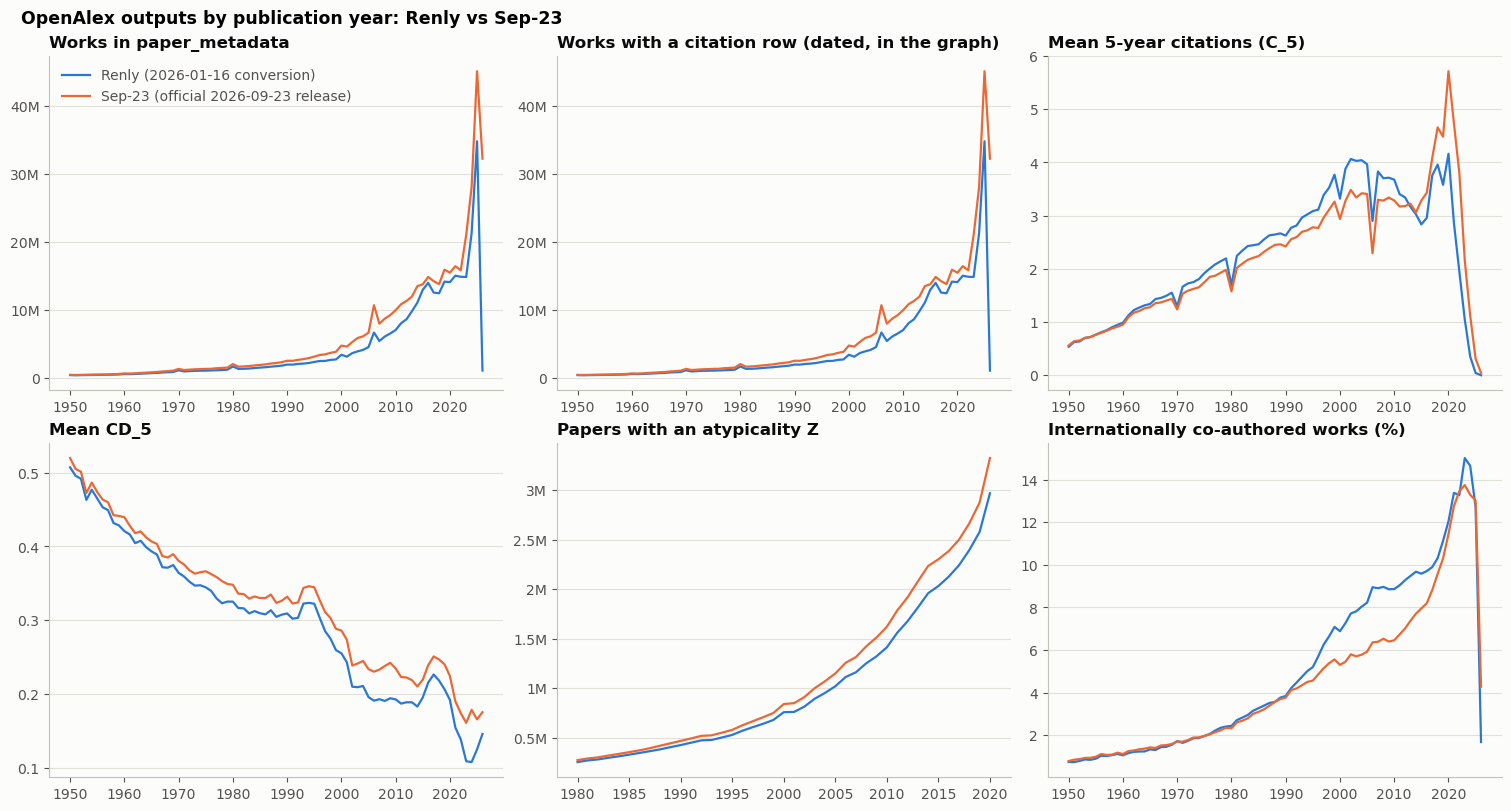

done in 10.7 min


In [5]:
SURF, INK, INK2, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#e1e0d9', '#c3c2b7'
C = {'renly': '#2a78d6', 'sep23': '#eb6834'}
NAME = {'renly': 'Renly (2026-01-16 conversion)', 'sep23': 'Sep-23 (official 2026-09-23 release)'}
TITLE = {'works': 'Works in paper_metadata', 'with_citation_row': 'Works with a citation row (dated, in the graph)',
         'mean_C5': 'Mean 5-year citations (C_5)', 'mean_CD5': 'Mean CD_5', 'z_scored': 'Papers with an atypicality Z',
         'international_pct': 'Internationally co-authored works (%)'}
plt.rcParams.update({'font.size': 10, 'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'xtick.color': INK2, 'ytick.color': INK2,
                     'axes.titlecolor': INK, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left', 'figure.facecolor': SURF, 'axes.facecolor': SURF})
series = [s for s in TITLE if s in set(w.series)]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for a, s in zip(axes.flat, series):
    x = w[w.series == s]
    for v in ('renly', 'sep23'):
        if v in x:
            a.plot(x.y, x[v], color=C[v], lw=1.6, label=NAME[v])
    a.set_title(TITLE[s]); a.grid(axis='y', color=GRID, lw=0.8); a.set_axisbelow(True)
    for sp in ('top', 'right'): a.spines[sp].set_visible(False)
    if s in ('works', 'with_citation_row', 'z_scored'):
        a.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v / 1e6:,.3g}M' if v else '0'))   # 0.5M steps need the decimal
for a in axes.flat[len(series):]:
    a.axis('off')
axes.flat[0].legend(frameon=False, loc='upper left', labelcolor=INK2)
fig.suptitle('OpenAlex outputs by publication year: Renly vs Sep-23', x=0.01, ha='left', fontsize=12.5, fontweight='bold')
fig.savefig(f'{FIG}/output_comparison_by_year.png', dpi=200, facecolor=SURF)
plt.show()
print(f'done in {(time.time() - t00) / 60:.1f} min')

## 4. Yearly totals of the trend tables

In [6]:
for t, sql in (('paper_citation_trend.parquet', "SELECT cite_year y, sum(p2p) p2p, sum(pat2p_examiner + pat2p_non_examiner) pat2p FROM {s} GROUP BY 1"),
               ('paper_disruption_trend_summary.parquet', "SELECT pub_year y, avg(CD_mean) CD_mean_over_ages, sum(n_CD) n_CD FROM {s} GROUP BY 1")):
    if not (readable(OLD, t) and readable(NEW, t)):
        print(f'{t}: not in both versions yet'); continue
    o = q(sql.format(s=src(OLD, t))).set_index('y'); n = q(sql.format(s=src(NEW, t))).set_index('y')
    x = o.join(n, lsuffix='_renly', rsuffix='_sep23', how='outer').sort_index()
    print(f'\n{t}:'); print(x.loc[[y for y in (1990, 2000, 2010, 2015, 2020, 2023, 2024, 2025) if y in x.index]].round(4).to_string())


paper_citation_trend.parquet:
        p2p_renly  pat2p_renly    p2p_sep23  pat2p_sep23
y                                                       
1990    9513269.0      49535.0   11164902.0      55097.0
2000   20862613.0     371132.0   25237556.0     408901.0
2010   54817861.0     968945.0   69277027.0    1076889.0
2015   81168784.0    1459832.0  100738412.0    1633364.0
2020  129825246.0    1628538.0  161793282.0    1841882.0
2023  104773083.0    1528116.0  185248403.0    1715566.0
2024  116012467.0    1556639.0  215840020.0    1748803.0
2025  130447474.0    1566411.0  222089558.0    1763165.0

paper_disruption_trend_summary.parquet:
      CD_mean_over_ages_renly  n_CD_renly  CD_mean_over_ages_sep23  n_CD_sep23
y                                                                             
1990                   0.1284  18808902.0                   0.1433  21513299.0
2000                   0.1017  23853118.0                   0.1154  27905641.0
2010                   0.0602  30802126.0 